# AI-Driven Customer Purchase Behavior Analysis

## Project Objective
The goal of this project is to analyze customer demographic and purchasing behavior data to identify patterns that influence spending. This analysis helps uncover meaningful business insights and supports future machine learning applications such as purchase prediction and customer segmentation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

## 1. Data Loading

In this section, the dataset is loaded and the basic structure is reviewed to understand the available features and target variable.

In [2]:
# Load dataset
df = pd.read_csv("../data/customer_purchases.csv")

df.head()

,CustomerID,Age,Gender,PurchaseAmount,ProductCategory
0,1,25,Male,120.50,Electronics
1,2,34,Female,80.00,Clothing
2,3,45,Female,45.30,Grocery
3,4,23,Male,200.00,Electronics
4,5,56,Female,150.75,Home


In [3]:
# Basic Info

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (100, 5)

Columns: ['CustomerID', 'Age', 'Gender', 'PurchaseAmount', 'ProductCategory']

Missing Values:
 CustomerID         0
Age                0
Gender             0
PurchaseAmount     0
ProductCategory    0
dtype: int64


## 2. Data Preprocessing

This step checks for missing values, duplicate records, and data type issues. Basic cleaning is performed to prepare the data for analysis.

    missing values
    cleaning
    data types

In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Convert Gender and ProductCategory to category
df["Gender"] = df["Gender"].astype("category")
df["ProductCategory"] = df["ProductCategory"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CustomerID       100 non-null    int64   
 1   Age              100 non-null    int64   
 2   Gender           100 non-null    category
 3   PurchaseAmount   100 non-null    float64 
 4   ProductCategory  100 non-null    category
dtypes: category(2), float64(1), int64(2)
memory usage: 3.0 KB


## 3. Univariate Analysis

Univariate analysis is used to examine the distribution of individual variables such as age, gender, and purchase amount. This helps identify central patterns, variation, and possible outliers.

    distributions
    summary stats

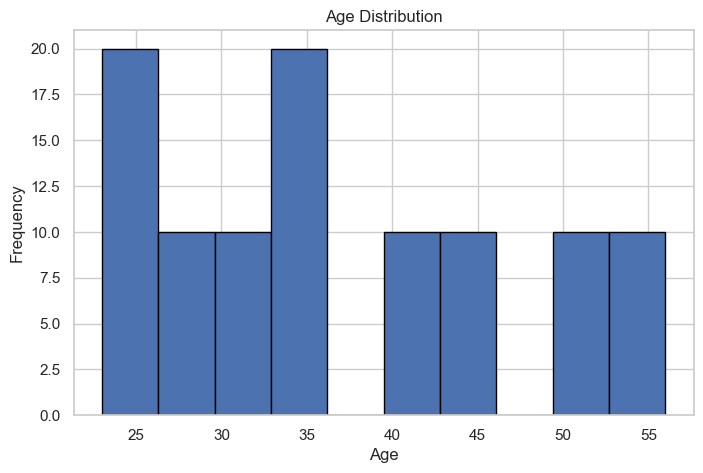

In [6]:
# Age Distribution

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

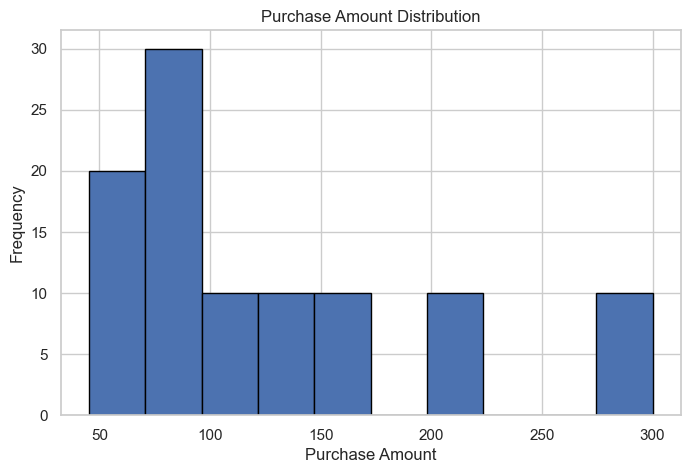

In [20]:
# Purchase Distribution

plt.figure(figsize=(8,5))
plt.hist(df["PurchaseAmount"], bins=10, edgecolor="black")

plt.savefig("../images/purchase_distribution.png", bbox_inches="tight")

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

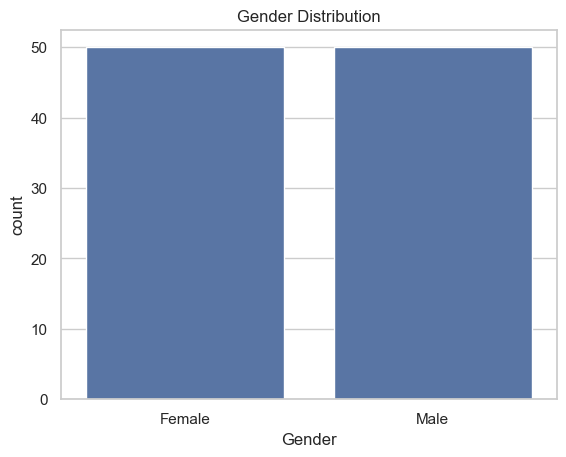

In [8]:
# Gender Distribution

sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

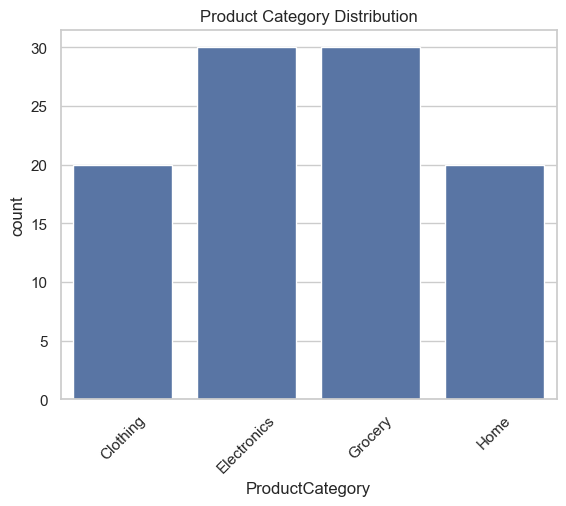

In [9]:
# Product Category Distribution

sns.countplot(x="ProductCategory", data=df)
plt.title("Product Category Distribution")
plt.xticks(rotation=45)
plt.show()

## 4. Bivariate Analysis

Bivariate analysis helps identify relationships between two variables. In this project, relationships between demographic features and purchase behavior are examined to understand spending trends across customer groups.

    relationships
    comparisons

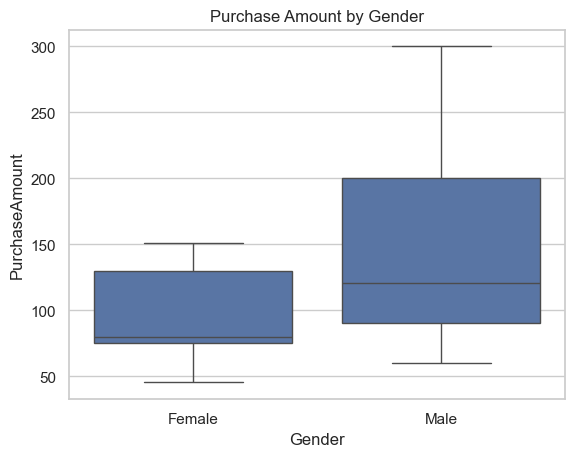

In [21]:
# Gender vs Purchase

sns.boxplot(x="Gender", y="PurchaseAmount", data=df)

plt.savefig("../images/gender_vs_purchase.png", bbox_inches="tight")

plt.title("Purchase Amount by Gender")
plt.show()

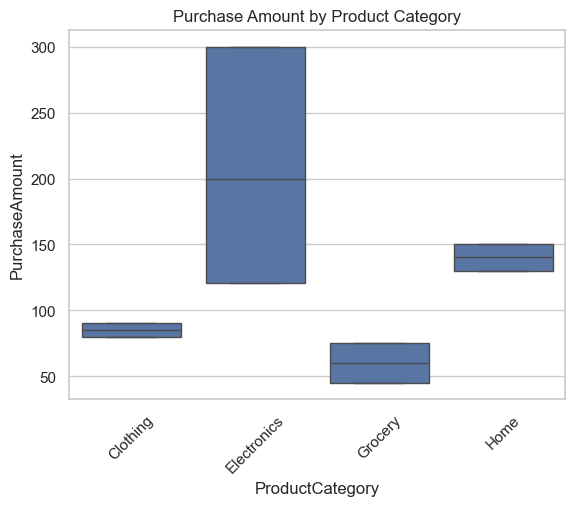

In [11]:
# Category vs Purchase

sns.boxplot(x="ProductCategory", y="PurchaseAmount", data=df)
plt.title("Purchase Amount by Product Category")
plt.xticks(rotation=45)
plt.show()

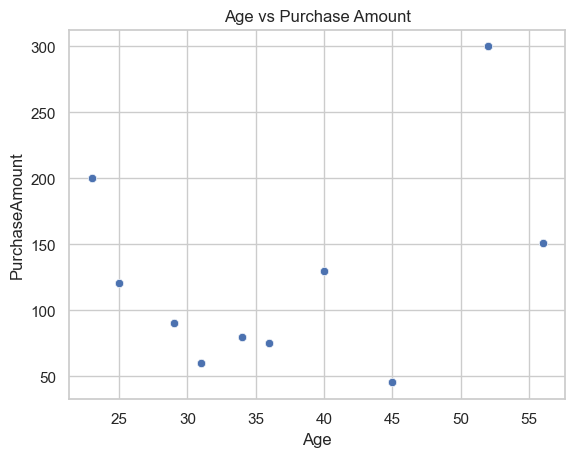

In [12]:
# Age vs Purchase

sns.scatterplot(x="Age", y="PurchaseAmount", data=df)
plt.title("Age vs Purchase Amount")
plt.show()

## 5. Multivariate Analysis

Multivariate analysis is used to explore relationships among multiple variables at the same time. This helps identify stronger patterns, correlations, and feature interactions that may not be visible in univariate or bivariate analysis.

    correlation heatmap
    feature interactions
    PCA (if you did)
    multiple relationships

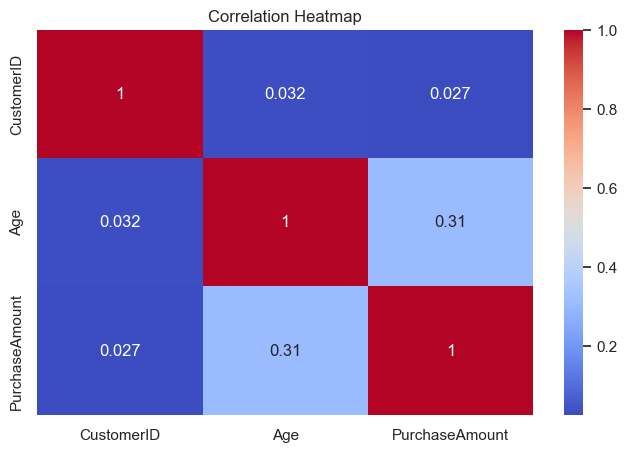

In [22]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.savefig("../images/correlation_heatmap.png", bbox_inches="tight")

plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Group Analysis (Important Insight)

grouped = df.groupby(["Gender", "ProductCategory"])["PurchaseAmount"].mean()
print(grouped)

Gender  ProductCategory
Female  Clothing            80.000000
        Electronics               NaN
        Grocery             60.400000
        Home               140.375000
Male    Clothing            90.200000
        Electronics        206.833333
        Grocery             60.000000
        Home                      NaN
Name: PurchaseAmount, dtype: float64


/var/folders/v7/bb37xc317z11w0fdz8vt2n_w0000gn/T/ipykernel_14432/770831235.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["Gender", "ProductCategory"])["PurchaseAmount"].mean()


The multivariate analysis showed how several features interact with purchase behavior at the same time. Correlation patterns helped identify which variables may be useful for future predictive modeling.

## 6. Introduction to Modeling

A simple predictive modeling step was included to test whether customer purchase amount could be estimated from the available features. This provides an initial view of the dataset’s potential for supervised machine learning.

    model used (Random Forest / regression etc.)
    evaluation metric (RMSE etc.)
    simple explanation

In [15]:
# Prepare Data

# Convert categorical variables
model_df = pd.get_dummies(df, drop_first=True)

X = model_df.drop(columns=["PurchaseAmount", "CustomerID"])
y = model_df["PurchaseAmount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# Train Model

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [17]:
# Evaluate Model

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.435439433216608
R2 Score: 0.9999501531776165


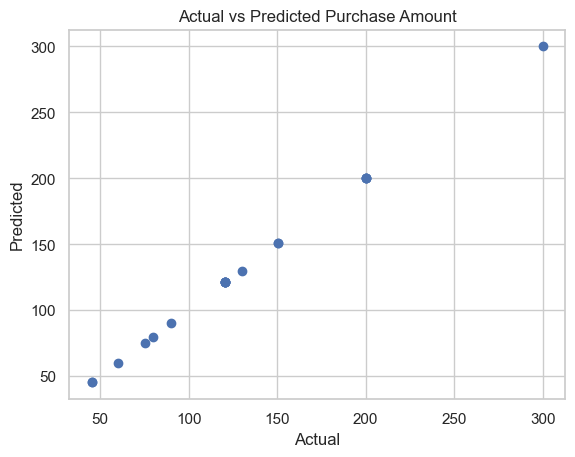

In [23]:
# Plot Results

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.savefig("../images/actual_vs_predicted.png", bbox_inches="tight")

plt.title("Actual vs Predicted Purchase Amount")
plt.show()

## 7. Key Insights

- Customers in Electronics category tend to have higher purchase amounts  
- Purchase behavior varies across product categories  
- Age shows some variation in spending but is not the strongest predictor  
- Gender-based differences exist but are moderate  
- Product category is one of the strongest influencing factors  

## 8. Conclusion

This project demonstrates a full data analysis workflow including preprocessing, exploratory analysis, multivariate analysis, and basic predictive modeling.

The analysis highlights key factors influencing customer purchase behavior and provides a foundation for future machine learning applications such as purchase prediction and customer segmentation.

## Business Insights & Story

The analysis reveals that customer purchase behavior is influenced more by product category than by demographic features such as age or gender.

Customers purchasing Electronics and Home products tend to have higher spending patterns, indicating that product type plays a key role in revenue generation.

While age shows some variation in spending, it is not the strongest predictor. Gender differences exist but are relatively moderate.

Overall, the findings suggest that businesses can improve revenue by focusing on high-value product categories and targeting customers based on purchasing behavior rather than only demographics.

## Recommendations

- Focus marketing efforts on high-spending product categories such as Electronics  
- Use purchase behavior data for customer segmentation  
- Apply machine learning models to predict customer spending  
- Improve personalization strategies based on purchasing patterns  